# Learning about the Capital asset pricing model

In [2]:
import pandas as pd
import seaborn as sns
import plotly.express as px
from copy import copy
import matplotlib.pyplot as plt
import numpy as np
import plotly.figure_factory as ff
import plotly.graph_objects as go

In [3]:
from jupyterthemes import jtplot  # Jupyter theme

jtplot.style(theme="monokai", context="notebook", ticks=True, grid=False)

In [4]:
df = pd.read_csv("stocks_dataset.csv")
df.head()

,Date,FB,TWTR,NFLX,BA,T,MGM,TSLA,sp500
0,11/7/2013,47.560001,44.900002,46.694286,131.509995,35.110001,18.580000,139.770004,1747.150024
1,11/8/2013,47.529999,41.650002,47.842857,133.490005,35.169998,19.090000,137.949997,1770.609985
2,11/11/2013,46.200001,42.900002,48.272858,132.529999,35.029999,19.200001,144.699997,1771.890015
3,11/12/2013,46.610001,41.900002,47.675713,132.330002,35.169998,19.260000,137.800003,1767.689941
4,11/13/2013,48.709999,42.599998,47.897144,133.169998,35.070000,19.700001,138.699997,1782.000000


## Descriptive stats

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1699 non-null   str    
 1   FB      1699 non-null   float64
 2   TWTR    1699 non-null   float64
 3   NFLX    1699 non-null   float64
 4   BA      1699 non-null   float64
 5   T       1699 non-null   float64
 6   MGM     1699 non-null   float64
 7   TSLA    1699 non-null   float64
 8   sp500   1699 non-null   float64
dtypes: float64(8), str(1)
memory usage: 119.6 KB


In [6]:
df.describe()

,FB,TWTR,NFLX,BA,T,MGM,TSLA,sp500
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,135.966863,31.296698,195.423654,218.325633,35.296986,25.720865,311.299388,2413.219428
std,50.062473,11.508628,127.700712,98.968191,3.412142,5.200605,203.097452,424.825240
min,44.820000,14.010000,44.887142,95.010002,26.770000,7.140000,120.500000,1741.890015
25%,88.080002,19.600001,90.474998,132.840004,32.790001,21.935001,218.829994,2053.294921
50%,136.759995,31.610001,143.830002,158.289993,34.900002,25.879999,253.740005,2360.159912
75%,178.075005,38.229999,320.024993,334.360001,38.004999,29.250000,323.565002,2783.330078
max,268.440002,73.309998,548.729980,440.619995,43.470001,38.029999,1643.000000,3386.149902


In [7]:
# Index the data to the first day of the dataset
df_norm = copy(df)
for col in df.columns[1 : len(df.columns)]:
    df_norm[col] = df[col] / (df.iloc[0][col])

df_norm.head()

,Date,FB,TWTR,NFLX,BA,T,MGM,TSLA,sp500
0,11/7/2013,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,11/8/2013,0.999369,0.927617,1.024598,1.015056,1.001709,1.027449,0.986979,1.013428
2,11/11/2013,0.971405,0.955457,1.033807,1.007756,0.997721,1.033369,1.035272,1.014160
3,11/12/2013,0.980025,0.933185,1.021018,1.006235,1.001709,1.036598,0.985905,1.011756
4,11/13/2013,1.024180,0.948775,1.025760,1.012623,0.998861,1.060280,0.992345,1.019947


In [8]:
print(
    f"If you had invested $1000 in Netflix on the first day of the dataset ({df_norm.iloc[0].Date}), "
    + f"your investment would be worth: ${df_norm.iloc[-1]['NFLX'] * 1000:,.2f} on the last day of the dataset ({df_norm.iloc[-1].Date})."
)

If you had invested $1000 in Netflix on the first day of the dataset (11/7/2013), your investment would be worth: $10,595.09 on the last day of the dataset (8/7/2020).


In [9]:
def make_plt(df, x_col, y_col, title, add_zero_line=False):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.xticks(range(0, len(df), 90))  # Show every 90th date for better readability
    plt.tight_layout()
    if add_zero_line:
        plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.show()

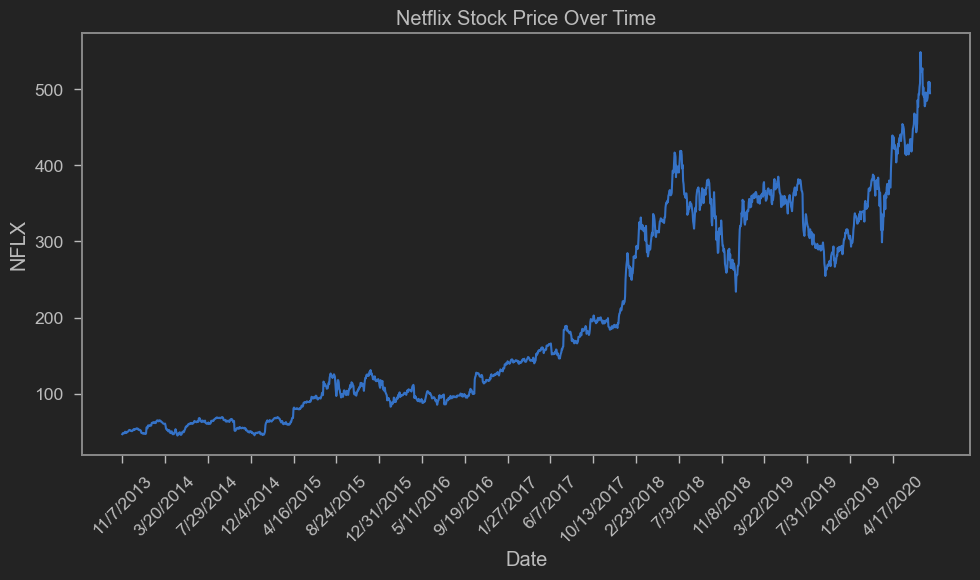

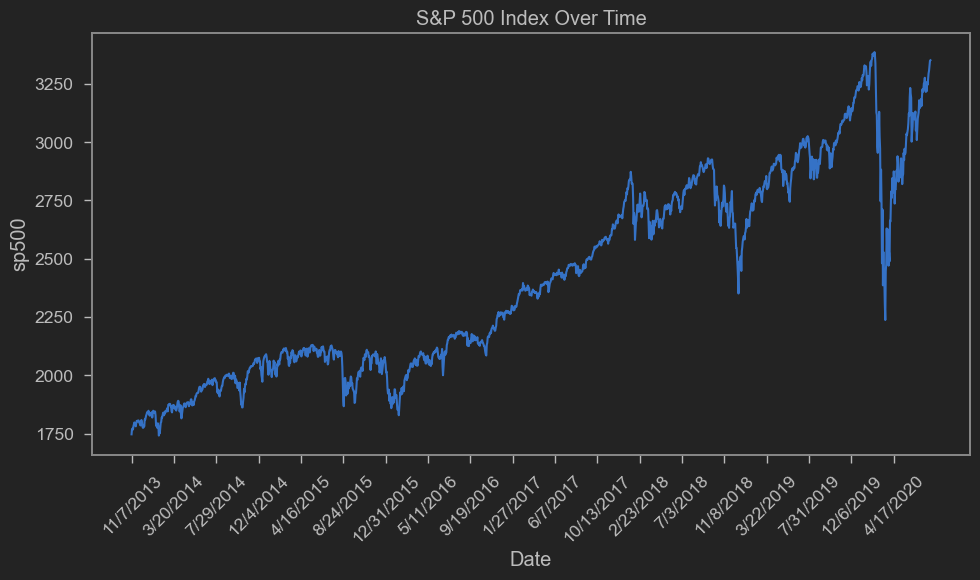

In [10]:
make_plt(df, "Date", "NFLX", "Netflix Stock Price Over Time")
make_plt(df, "Date", "sp500", "S&P 500 Index Over Time")

In [11]:
def make_interactive_plt(df, x_col, title):
    fig = px.line(title=title)
    for i in df.columns[1:]:
        fig.add_scatter(x=df[x_col], y=df[i], mode="lines", name=i)
    fig.update_xaxes(tickangle=-45)
    fig.show()

In [12]:
make_interactive_plt(df, "Date", "Stock Prices Over Time")

In [13]:
def daily_returns(df):
    df_returns = copy(df)
    for col in df.columns[1 : len(df.columns)]:
        df_returns[col] = df[col].pct_change() * 100
    return df_returns

In [14]:
dr = daily_returns(df)
dr.head()

,Date,FB,TWTR,NFLX,BA,T,MGM,TSLA,sp500
0,11/7/2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11/8/2013,-0.063082,-7.238307,2.459768,1.505597,0.170883,2.744887,-1.302144,1.342756
2,11/11/2013,-2.798229,3.001200,0.898778,-0.719159,-0.398064,0.576223,4.893077,0.072293
3,11/12/2013,0.887446,-2.331002,-1.237020,-0.150907,0.399655,0.312495,-4.768482,-0.237039
4,11/13/2013,4.505467,1.670635,0.464452,0.634774,-0.284328,2.284533,0.653116,0.809534


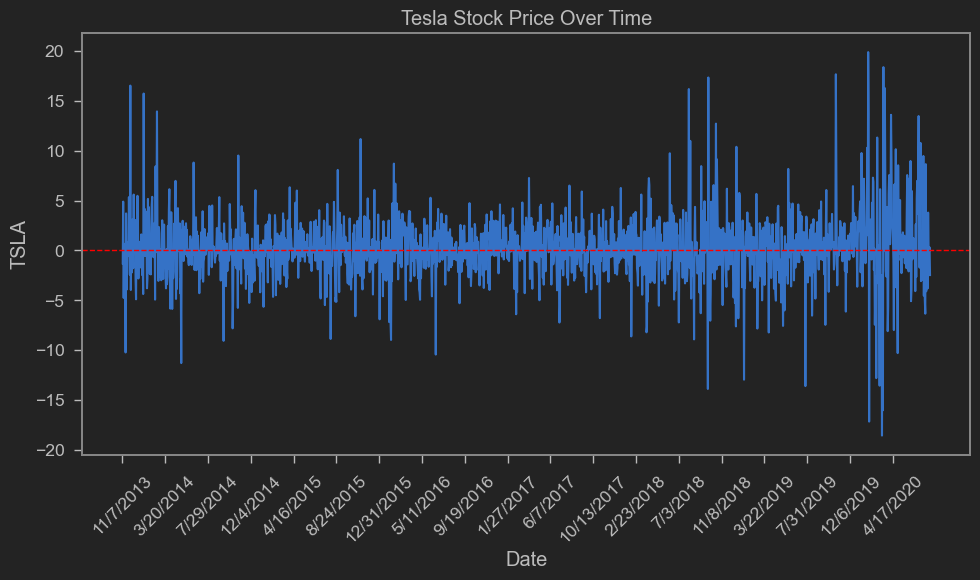

In [15]:
make_plt(dr, "Date", "TSLA", "Tesla Stock Price Over Time", add_zero_line=True)

## Calculate Beta

In [16]:
tsla = df[["Date", "TSLA"]]
sp = df[["Date", "sp500"]]

CAPM formula: $$E(R_i) = R_f + \beta_i \left[ E(R_m) - R_f \right]$$

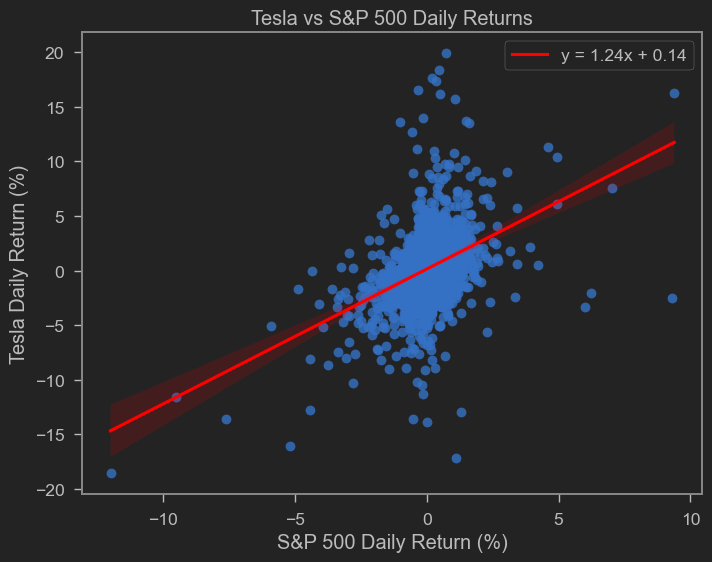

In [17]:
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=dr, x="sp500", y="TSLA", label="Daily Returns")
# plt.title("Tesla vs S&P 500 Daily Returns")
# plt.xlabel("S&P 500 Daily Return (%)")
# plt.ylabel("Tesla Daily Return (%)")
# plt.axhline(0, color="red", linestyle="--", linewidth=1)
# plt.axvline(0, color="red", linestyle="--", linewidth=1)
# plt.legend()
# plt.tight_layout()
# plt.show()

# 1. Calculate regression parameters
a, b = np.polyfit(dr["sp500"].dropna(), dr["TSLA"].dropna(), 1)

formula = f"y = {a:.2f}x + {b:.2f}"

# 2. Plot with seaborn
plt.figure(figsize=(8, 6))
ax = sns.regplot(
    x="sp500",
    y="TSLA",
    data=dr,
    line_kws={"color": "red", "label": formula},
    scatter_kws={"s": 50},
)

plt.title("Tesla vs S&P 500 Daily Returns")
plt.xlabel("S&P 500 Daily Return (%)")
plt.ylabel("Tesla Daily Return (%)")
plt.legend()
plt.show()


In [18]:
a, b = np.polyfit(dr["sp500"].dropna(), dr["MGM"].dropna(), 1)
formula = f"y = {a:.2f}x + {b:.2f}"
print(formula)

y = 1.65x + -0.03


In [24]:
# calculate capm formula for a company
def calc_capm(dr, stock, verbose=False):
    a, b = np.polyfit(dr["sp500"].dropna(), dr[stock].dropna(), 1)

    beta = a
    rm = dr["sp500"].mean() * 252  # annualize the mean return
    rf = dr["T"].mean() * 252  # annualize the treasury return
    ER = rf + beta * (rm - rf)
    if verbose:
        print(f"Beta: {beta:.2f}")
        print(f"Market Return: {rm:.2f}")
        print(f"Risk-Free Rate: {rf:.2f}")
    print(f"Expected Return for {stock}: {ER:.2f}")
    if verbose:
        print("____________________")

In [27]:
for i in dr.columns[1:]:
    calc_capm(dr, i, verbose=False)

Expected Return for FB: 12.33
Expected Return for TWTR: 13.19
Expected Return for NFLX: 11.74
Expected Return for BA: 16.10
Expected Return for T: 8.44
Expected Return for MGM: 18.61
Expected Return for TSLA: 13.91
Expected Return for sp500: 11.24
